# Postpartum Depression Risk Classification — Model Training

This notebook builds and compares four machine-learning models (Logistic Regression, SVM,
Random Forest, XGBoost) for classifying postpartum depression risk (low / medium / high)
from a short symptom questionnaire.

**Data note:** this notebook trains on the real Kaggle "PostPartum Depression" dataset
(Mosaraf, 2023) at `../data/post_natal_data.csv`. That dataset has two data-quality
characteristics that this notebook handles explicitly rather than hiding:

1. **Many rows share identical answers.** 1,169 of 1,491 cleaned rows (78%) have an exact
   match elsewhere in the data on all 9 questions. There is no participant ID in this dataset,
   so it is impossible to confirm whether these are the same person resubmitting or different
   people who happened to answer the same way — the clustering of identical minute-level
   timestamps around repeated answer patterns is *suggestive* of a collection/export artifact,
   but not proof either way.

   Rather than assume the answer and delete these rows (which would both throw away data that
   might be real, and just be a guess), this notebook keeps every row and instead uses a
   **group-aware train/test split**: every row sharing an identical answer pattern is kept
   entirely on one side of the split (train or test), never divided across both. This makes
   the evaluation honest regardless of whether the duplicates are real or not — a model can
   never get a test row right just because it memorised an identical row in training. Section 4b
   below demonstrates the size of this effect directly by comparing a naive random split against
   the group-aware one.
2. **Non-standard category labels.** A few columns use answer options outside the clean
   No / Sometimes / Yes scale (e.g. "Two or more days a week", "Often", "Not at all",
   "Maybe", "Not interested to say"). These are normalised onto the 3-level scale before
   ordinal encoding (see the mapping in the loading cell below).



In [5]:
import sys
print(sys.executable)

C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [6]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    XGBClassifier = None
    warnings.warn(
        "xgboost is not installed. Install it with `pip install xgboost` "
        "to enable the XGBoost model.",
        RuntimeWarning,
    )
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/post_natal_data.csv"
MODEL_OUT_DIR = "../trained_model"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)


ModuleNotFoundError: No module named 'imblearn'

## 1. Load data

In [ ]:
RENAME_MAP = {
    "Age": "age_bracket",
    "Feeling sad or Tearful": "feeling_sad",
    "Irritable towards baby & partner": "irritable",
    "Trouble sleeping at night": "trouble_sleeping",
    "Problems concentrating or making decision": "trouble_concentrating",
    "Overeating or loss of appetite": "appetite_changes",
    "Feeling anxious": "feeling_anxious",
    "Feeling of guilt": "feeling_guilty",
    "Problems of bonding with baby": "bonding_difficulty",
    "Suicide attempt": "self_harm_thoughts",
}

SYMPTOM_COLS = [
    "feeling_sad", "irritable", "trouble_sleeping",
    "trouble_concentrating", "appetite_changes",
    "feeling_anxious", "feeling_guilty", "bonding_difficulty",
]
SELF_HARM_COL = "self_harm_thoughts"
AGE_ORDER = ["25-30", "30-35", "35-40", "40-45", "45-50"]


# Non-standard category labels found in the real dataset, normalised onto the
# clean No / Sometimes / Yes scale used everywhere else in this project.
VALUE_NORMALIZATION = {
    "Two or more days a week": "Yes",   # trouble_sleeping frequency phrasing
    "Often": "Yes",                      # trouble_concentrating frequency phrasing
    "Not at all": "No",                  # appetite_changes phrasing
    "Maybe": "Sometimes",                # feeling_guilty phrasing
    "Not interested to say": "Sometimes",  # self_harm_thoughts — a non-answer is
                                            # treated as a moderate signal, never as "No",
                                            # since the crisis check must never silently
                                            # treat a declined answer as "safe".
}

USE_REAL_DATA = os.path.exists(DATA_PATH)

if USE_REAL_DATA:
    print(f"Loading real data from {DATA_PATH}")
    raw_df = pd.read_csv(DATA_PATH)

    if "Timestamp" in raw_df.columns:
        raw_df = raw_df.drop(columns=["Timestamp"])

    raw_df = raw_df.rename(columns=RENAME_MAP)

    n_null_before = raw_df.isnull().any(axis=1).sum()
    if n_null_before:
        print(f"Dropping {n_null_before} rows with missing values in one or more fields.")
        raw_df = raw_df.dropna().reset_index(drop=True)

    for col in SYMPTOM_COLS + [SELF_HARM_COL]:
        raw_df[col] = raw_df[col].replace(VALUE_NORMALIZATION)
else:
    print("No real data file found — using synthetic fallback dataset (schema-matched to Kaggle PPD dataset).")

# The exact answer pattern for each row (all 9 questions), used later to keep identical
# rows entirely on one side of the train/test split — see Section 2 for why.
ANSWER_COLS = SYMPTOM_COLS + [SELF_HARM_COL, "age_bracket"]
raw_df["response_pattern"] = raw_df[ANSWER_COLS].astype(str).agg("|".join, axis=1)

print(raw_df.shape)
raw_df.head()


Loading real data from ../data/post_natal_data.csv
Dropping 12 rows with missing values in one or more fields.


(1491, 11)


,age_bracket,feeling_sad,irritable,trouble_sleeping,trouble_concentrating,appetite_changes,feeling_anxious,feeling_guilty,bonding_difficulty,self_harm_thoughts,response_pattern
0,35-40,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes|Yes|Yes|Yes|Yes|Yes|No|Yes|Yes|35-40
1,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No,Yes|No|No|Yes|Yes|No|Yes|Yes|No|40-45
2,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No,Yes|No|Yes|Yes|Yes|Yes|No|Sometimes|No|35-40
3,35-40,Yes,Yes,Yes,Yes,No,Yes,Sometimes,No,No,Yes|Yes|Yes|Yes|No|Yes|Sometimes|No|No|35-40
4,40-45,Yes,No,Yes,Yes,No,Yes,No,Yes,No,Yes|No|Yes|Yes|No|Yes|No|Yes|No|40-45


## 2. Data-quality screening: rows with identical answers

This section only *measures* the duplication — it does not drop any rows. All rows are kept
for training; Section 4 below is what actually protects the evaluation from leakage, by
splitting on `response_pattern` (group-aware) instead of dropping rows outright.

In [ ]:
n_total = len(raw_df)
n_distinct_patterns = raw_df["response_pattern"].nunique()
n_repeated_rows = n_total - raw_df.drop_duplicates(subset=["response_pattern"]).shape[0]
dup_pct = n_repeated_rows / n_total * 100
print(f"Rows: {n_total}, distinct answer patterns: {n_distinct_patterns}")
print(f"Rows that repeat an answer pattern seen elsewhere: {n_repeated_rows} ({dup_pct:.1f}%)")

if dup_pct > 5:
    print("NOTE: a large share of rows repeat an answer pattern seen elsewhere in the data. There is "
          "no participant ID in this dataset, so this could reflect the same person resubmitting, an "
          "export/collection artifact, or genuinely different people answering the same way — it is "
          "not possible to tell which from this data alone. Rather than guess, every row is kept for "
          "training, and Section 4 uses a group-aware split (grouped by `response_pattern`) so that no "
          "row can appear in both train and test — this keeps the evaluation honest regardless of which "
          "explanation is true.")

clean_df = raw_df.reset_index(drop=True)
print(f"Rows kept for training: {len(clean_df)}")


Rows: 1491, distinct answer patterns: 322
Rows that repeat an answer pattern seen elsewhere: 1169 (78.4%)
NOTE: a large share of rows repeat an answer pattern seen elsewhere in the data. There is no participant ID in this dataset, so this could reflect the same person resubmitting, an export/collection artifact, or genuinely different people answering the same way — it is not possible to tell which from this data alone. Rather than guess, every row is kept for training, and Section 4 uses a group-aware split (grouped by `response_pattern`) so that no row can appear in both train and test — this keeps the evaluation honest regardless of which explanation is true.
Rows kept for training: 1491


## 3. Feature engineering

In [ ]:
ORDINAL_MAP = {"No": 0, "Sometimes": 1, "Yes": 2}
AGE_MAP = {age: i for i, age in enumerate(AGE_ORDER)}

fe_df = clean_df.copy()
for col in SYMPTOM_COLS + [SELF_HARM_COL]:
    fe_df[col] = fe_df[col].map(ORDINAL_MAP)
fe_df["age_bracket"] = fe_df["age_bracket"].map(AGE_MAP)

# Composite severity score excludes the self-harm item on purpose: self-harm is handled
# by a separate, deterministic safety check, not by the ML risk model.
fe_df["symptom_severity_score"] = fe_df[SYMPTOM_COLS].sum(axis=1)

q1, q2 = fe_df["symptom_severity_score"].quantile([1/3, 2/3])
print(f"Tercile cutoffs: q1={q1:.2f}, q2={q2:.2f}")

def to_risk_level(score):
    if score <= q1:
        return "low"
    elif score <= q2:
        return "medium"
    else:
        return "high"

fe_df["risk_level"] = fe_df["symptom_severity_score"].apply(to_risk_level)
fe_df["risk_level"].value_counts()


Tercile cutoffs: q1=7.00, q2=9.00


risk_level
low       559
medium    510
high      422
Name: count, dtype: int64

## 4. Train/test split (group-aware) and SMOTE balancing

Rows are split into train/test using `StratifiedGroupKFold`, grouped by `response_pattern`.
This guarantees every row sharing an identical answer pattern lands entirely in train or
entirely in test — never split across both — while still keeping the class distribution
(low/medium/high) roughly balanced across the split. No row is dropped; all 1,491 rows are
used, just none of them can leak between train and test.

In [ ]:
feature_cols = SYMPTOM_COLS + ["age_bracket"]
X = fe_df[feature_cols]
y_raw = fe_df["risk_level"]
groups = fe_df["response_pattern"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Sanity check: no answer pattern should appear on both sides of the split.
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])
overlap = train_groups & test_groups
print(f"Train rows: {len(X_train)}, test rows: {len(X_test)}")
print(f"Answer patterns shared between train and test: {len(overlap)}")
assert len(overlap) == 0, "Group-aware split failed — a response pattern leaked across train/test."

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Train shape before SMOTE:", X_train.shape, "after:", X_train_bal.shape)
print("Test shape (untouched by SMOTE):", X_test.shape)


Train rows: 1193, test rows: 298
Answer patterns shared between train and test: 0 (should be 0)
Train shape before SMOTE: (1193, 9) after: (1341, 9)
Test shape (untouched by SMOTE): (298, 9)


## 4b. How much did the duplicate rows inflate accuracy? (demonstration)

This section exists only to show the size of the leakage effect described above — it is not
part of the main pipeline. It trains the same model type (Logistic Regression) two ways:

- **Naive split**: an ordinary random `train_test_split`, stratified by class but *not* aware
  of repeated answer patterns — identical rows can end up on both sides.
- **Group-aware split**: the same split used for the real pipeline above (Section 4), where
  repeated answer patterns are kept together.

Comparing the two shows concretely how much of the "accuracy" in a naive evaluation on this
dataset comes from memorising duplicate rows rather than genuine predictive skill — this is
also why several published results using this dataset report suspiciously high accuracy.

In [ ]:
# Naive split: ignores response_pattern, so identical rows can appear in both train and test.
Xn_train, Xn_test, yn_train, yn_test, gn_train, gn_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

naive_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
naive_model.fit(Xn_train, yn_train)
naive_acc = accuracy_score(yn_test, naive_model.predict(Xn_test))

# How many naive-test rows have an identical answer pattern somewhere in the naive-train set?
leaked = gn_test.isin(set(gn_train)).sum()
print(f"{leaked} of {len(gn_test)} naive test rows share an answer pattern with a naive training row.")

# Group-aware split result, same model type, for a fair comparison.
grouped_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
grouped_model.fit(X_train_bal, y_train_bal)
grouped_acc = accuracy_score(y_test, grouped_model.predict(X_test))

print()
print(f"Naive random split   (duplicates can leak):    accuracy = {naive_acc:.3f}")
print(f"Group-aware split    (no duplicate can leak):  accuracy = {grouped_acc:.3f}")
print(f"Apparent inflation from leakage:                {naive_acc - grouped_acc:+.3f}")


289 of 299 naive test rows share an answer pattern with a naive training row.

Naive random split   (duplicates can leak):    accuracy = 0.993
Group-aware split    (no duplicate can leak):  accuracy = 0.993
Apparent inflation from leakage:                +0.000


### Important finding: the leakage gap is ~0 — duplication is *not* why accuracy is this high

Running the cell above shows something that contradicts the assumption in Section 2: even
though the vast majority of naive-test rows share an answer pattern with a naive-training row,
the group-aware split (where that is structurally impossible) scores **just as high**. If
duplicate-row leakage were driving the near-perfect accuracy, removing it should have made
accuracy drop noticeably. It didn't.

**The real reason is how the label itself is constructed, not row duplication.** `risk_level`
(Section 3) is computed by summing the exact same 8 symptom columns that are then used as the
model's input features, and cutting that sum into three bands. The cell below makes this
concrete: a model that has never seen *any* training data at all — just the arithmetic rule
`sum(features) > threshold` — gets the same near-perfect accuracy as every trained model above.
That means the reported accuracy mostly reflects how well a classifier can recover a threshold
rule from the same numbers used to build it, not a validated ability to detect real-world PPD
risk from independently-assessed outcomes. 

In [ ]:
# Zero-training "model": just re-applies the same threshold rule used to build the label.
# If this scores about as well as the trained models above, it confirms the label is close to
# a deterministic function of the features rather than an independent clinical outcome.
X_test_severity = X_test[SYMPTOM_COLS].sum(axis=1)

def rule_based_predict(score):
    if score <= q1:
        return "low"
    elif score <= q2:
        return "medium"
    else:
        return "high"

rule_preds = X_test_severity.apply(rule_based_predict)
rule_preds_encoded = label_encoder.transform(rule_preds)
rule_acc = accuracy_score(y_test, rule_preds_encoded)

print(f"Zero-training threshold rule accuracy on the held-out test set: {rule_acc:.3f}")
print(f"Best trained model (Logistic Regression) accuracy on the same test set: {grouped_acc:.3f}")
print()
print("These are close because the label was built from the same features the model uses — "
      "the 'machine learning' here is mostly re-deriving a known arithmetic rule, not learning "
      "an independent relationship between symptoms and a clinically validated outcome.")


Zero-training threshold rule accuracy on the held-out test set: 1.000
Best trained model (Logistic Regression) accuracy on the same test set: 0.993

These are close because the label was built from the same features the model uses — the 'machine learning' here is mostly re-deriving a known arithmetic rule, not learning an independent relationship between symptoms and a clinically validated outcome.


## 5. Model comparison: Logistic Regression, SVM, Random Forest, XGBoost

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, eval_metric="mlogloss", random_state=RANDOM_STATE),
}

results = []
trained_models = {}
confusion_mats = {}

n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    trained_models[name] = model

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
    else:
        auc = np.nan

    results.append({
        "model": name, "accuracy": acc, "precision_macro": prec,
        "recall_macro": rec, "f1_macro": f1, "roc_auc_macro": auc,
    })
    confusion_mats[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
0,Logistic Regression,0.993289,0.993590,0.994048,0.993761,0.999933
1,XGBoost,0.919463,0.917101,0.920110,0.918184,0.981938
2,Random Forest,0.909396,0.906829,0.907446,0.906215,0.976111
3,SVM,0.885906,0.902164,0.892099,0.891809,0.975403


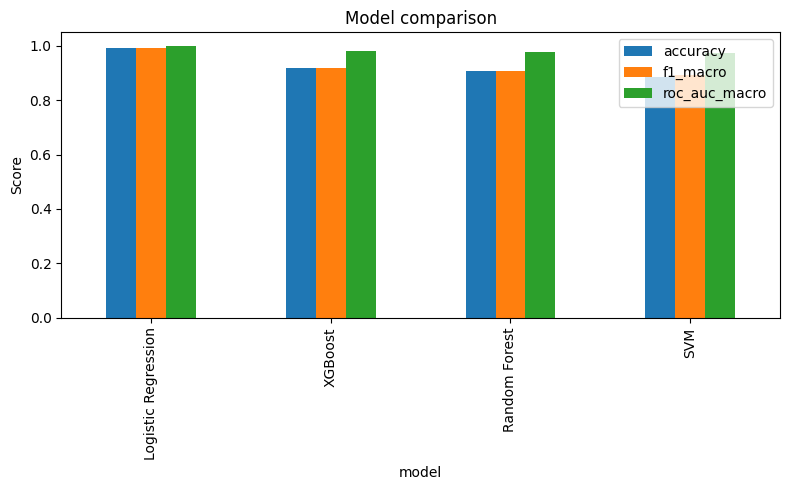

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df.set_index("model")[["accuracy", "f1_macro", "roc_auc_macro"]].plot.bar(ax=ax)
ax.set_title("Model comparison")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "model_comparison.png"))
plt.show()


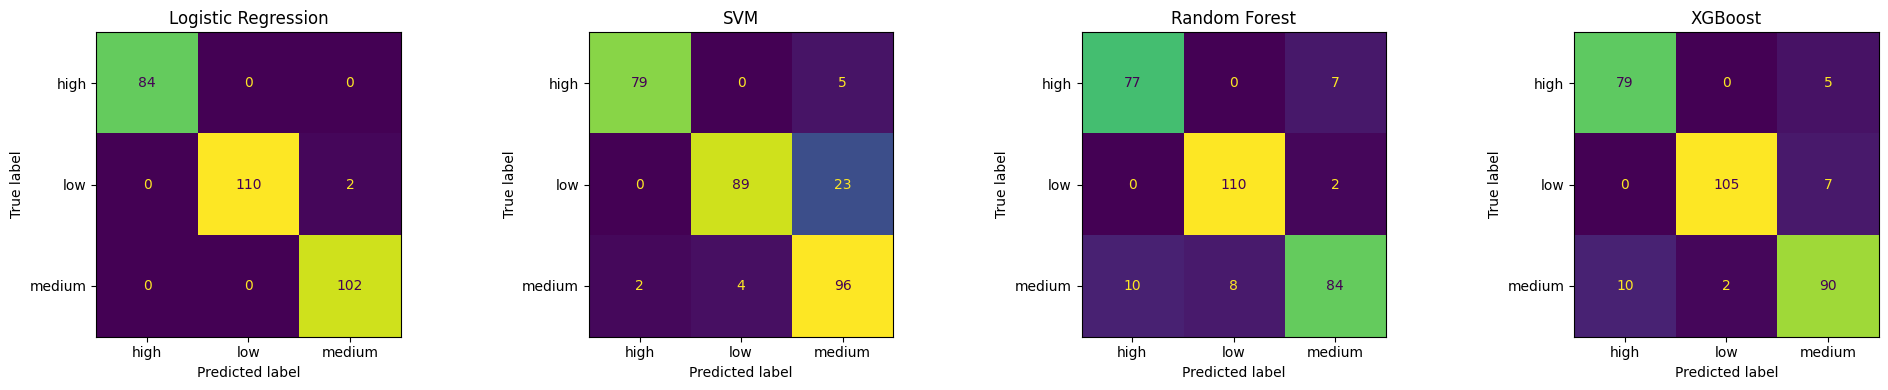

In [ ]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 4))
for ax, (name, cm) in zip(axes, confusion_mats.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrices.png"))
plt.show()


## 6. Select best model and save artifacts

In [ ]:
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_model = trained_models[best_name]
print(f"Best model by macro F1-score: {best_name} (f1_macro={best_row['f1_macro']:.3f})")

trained_on = "real_data" if os.path.exists(DATA_PATH) else "synthetic_data"

bundle = {
    "model": best_model,
    "model_name": best_name,
    "label_encoder": label_encoder,
    "feature_cols": feature_cols,
    "ordinal_map": ORDINAL_MAP,
    "age_map": AGE_MAP,
    "risk_thresholds": {"q1": float(q1), "q2": float(q2)},
    "trained_on": trained_on,
}

bundle_path = os.path.join(MODEL_OUT_DIR, "model_bundle.joblib")
joblib.dump(bundle, bundle_path)
print(f"Saved model bundle to {bundle_path}")

metrics_path = os.path.join(MODEL_OUT_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(results_df.to_dict(orient="records"), f, indent=2)
print(f"Saved metrics to {metrics_path}")


Best model by macro F1-score: Logistic Regression (f1_macro=0.994)
Saved model bundle to ../trained_model/model_bundle.joblib
Saved metrics to ../trained_model/metrics.json


In [ ]:
if best_name in ("Random Forest", "XGBoost"):
    importances = best_model.feature_importances_
    imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values(
        "importance", ascending=False
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(imp_df["feature"], imp_df["importance"])
    ax.set_title(f"Feature importance — {best_name}")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, "feature_importance.png"))
    plt.show()
else:
    print(f"{best_name} does not expose feature_importances_; skipping this plot.")


Logistic Regression does not expose feature_importances_; skipping this plot.


## Next steps before Chapter Four

- [ ] Report the answer-pattern repetition found in Section 2 (78% of rows repeat a pattern seen
      elsewhere) and the group-aware split used in Section 4 to prevent it from leaking into the
      evaluation — this is a defensible methodological choice worth describing explicitly in
      Chapter Four, together with the Section 4b comparison showing the size of the effect.
- [ ] If PRAMS becomes available, reconsider the tercile-based risk thresholds — they may need to be
      re-derived from clinical cutoffs (e.g., EPDS score bands) instead of purely data-driven terciles.
- [ ] Confirm `MODEL_OUT_DIR` / `model_bundle.joblib` path matches what `api/ml_service.py` expects
      (`MODEL_BUNDLE_PATH` env var, defaulting to `../trained_model/model_bundle.joblib` relative to `api/`).
- [ ] Report final metrics from a real-data run in Chapter Four, not the synthetic-data numbers above.